In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from pymargins import Margins

rng = np.random.default_rng(42)
n = 2000
df = pd.DataFrame(
    {
        "age": rng.integers(20, 75, n),
        "treatment": rng.binomial(1, 0.40, n),
    }
)
lp = -1.5 + 0.04 * df["age"] + 0.8 * df["treatment"]
df["y"] = rng.binomial(1, 1 / (1 + np.exp(-lp)))

fit = smf.glm("y ~ age + treatment", data=df, family=sm.families.Binomial()).fit()
m = Margins.log_scale(fit, at="overall")

In [2]:
from pymargins import grid

# grid() builds scenario dicts for use in contrasts/evaluate
print(grid(age=[25, 45, 65], treatment=[0, 1]))

# For predict, pass the grid directly as atexog
print(m.predict(atexog={"age": [25, 45, 65], "treatment": [0, 1]}).summary())

[{'atexog': {'age': 25, 'treatment': 0}, 'label': 'age=25, treatment=0'}, {'atexog': {'age': 25, 'treatment': 1}, 'label': 'age=25, treatment=1'}, {'atexog': {'age': 45, 'treatment': 0}, 'label': 'age=45, treatment=0'}, {'atexog': {'age': 45, 'treatment': 1}, 'label': 'age=45, treatment=1'}, {'atexog': {'age': 65, 'treatment': 0}, 'label': 'age=65, treatment=0'}, {'atexog': {'age': 65, 'treatment': 1}, 'label': 'age=65, treatment=1'}]


                    Margins Result (delta, level=0.95)                   
                     estimate  std err         z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------------------
age=25, treatment=0    0.3580   0.0585  -17.5681  0.000    0.3193, 0.4015
age=25, treatment=1    0.5712   0.0435  -12.8713  0.000    0.5245, 0.6221
age=45, treatment=0    0.5638   0.0267  -21.4557  0.000    0.5350, 0.5941
age=45, treatment=1    0.7553   0.0211  -13.3275  0.000    0.7248, 0.7871
age=65, treatment=0    0.7497   0.0221  -13.0360  0.000    0.7179, 0.7829
age=65, treatment=1    0.8773   0.0140   -9.3193  0.000    0.8535, 0.9018

n = 2000
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
κ: max=0.100
Delta-vs-sim disagreement: 0.666%


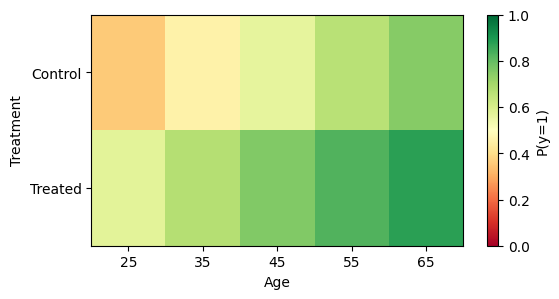

In [3]:
import matplotlib.pyplot as plt
import numpy as np

ages = np.arange(25, 66, 10)
treatments = [0, 1]
res = m.predict(atexog={"age": ages, "treatment": treatments})
df_grid = res.to_frame().pivot(index="treatment", columns="age", values="estimate")

fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(df_grid.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(ages)))
ax.set_xticklabels(ages)
ax.set_yticks(range(len(treatments)))
ax.set_yticklabels(["Control", "Treated"])
ax.set(xlabel="Age", ylabel="Treatment")
fig.colorbar(im, ax=ax, label="P(y=1)")